In [17]:
import os
os.environ["DDE_BACKEND"] = "tensorflow"

In [ ]:
!pip install deepxde

In [ ]:
!pip install tensorflow tf_keras matplotlib numpy scipy

Set the default float type to float64
Compiling model...
'compile' took 0.004969 s

Training model...

Step      Train loss                                  Test loss                                   Test metric
0         [2.22e-02, 1.30e-01, 1.14e+02, 2.59e+01]    [1.97e-02, 1.26e-01, 8.87e+01, 2.86e+01]    []  
1000      [1.90e+00, 1.49e+00, 4.36e+00, 4.68e+00]    [1.44e+00, 1.17e+00, 3.90e+00, 4.43e+00]    []  
2000      [1.44e-01, 4.61e-01, 2.38e-01, 7.36e-01]    [1.51e-01, 4.23e-01, 2.28e-01, 7.76e-01]    []  
3000      [9.39e-02, 1.75e-01, 1.37e-01, 2.78e-01]    [1.04e-01, 1.79e-01, 1.35e-01, 2.94e-01]    []  
4000      [6.38e-02, 9.67e-02, 9.90e-02, 1.47e-01]    [6.99e-02, 1.01e-01, 9.50e-02, 1.55e-01]    []  
5000      [4.27e-02, 5.91e-02, 7.06e-02, 8.96e-02]    [4.61e-02, 6.15e-02, 6.61e-02, 9.42e-02]    []  
6000      [2.86e-02, 3.66e-02, 5.11e-02, 5.08e-02]    [3.08e-02, 3.84e-02, 4.65e-02, 5.39e-02]    []  
7000      [1.93e-02, 2.43e-02, 9.39e-02, 8.88e-02]    [2.08e-02, 2

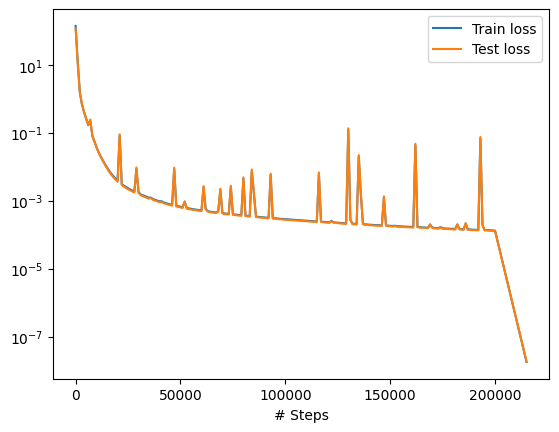

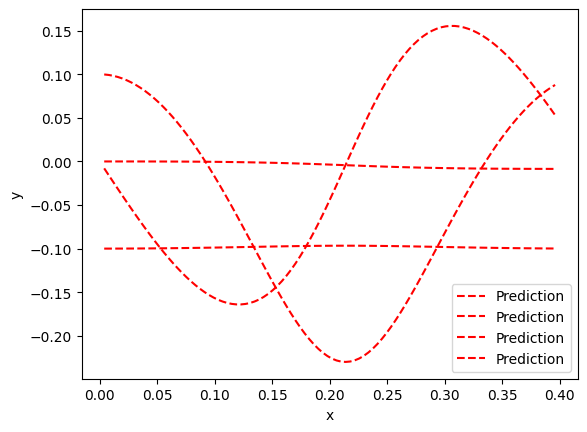

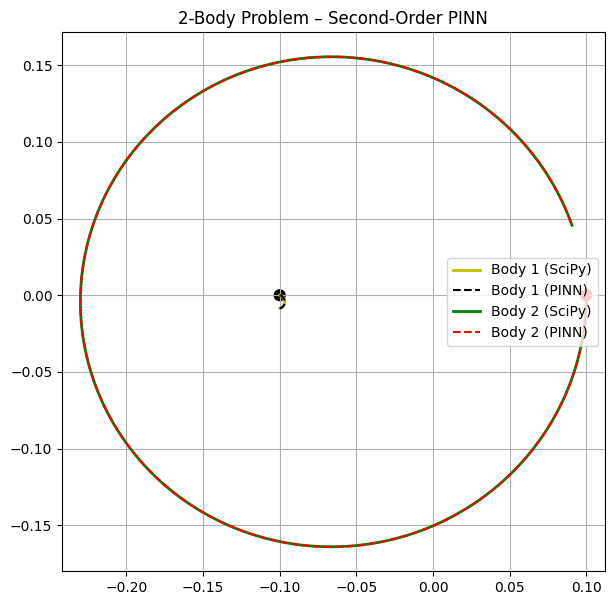

In [20]:
import deepxde as dde
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

dde.config.set_default_float("float64")

np.random.seed(137)
tf.random.set_seed(137)
dde.config.set_random_seed(137)

# --------------------------------------------------
# Constants
# --------------------------------------------------
G = 1.0
m1, m2 = 0.99, 0.01
endTime = 0.4


num_domain = 64
num_boundary = 12
num_test = 100

layer_size = [1] + [64]*3 + [4]  # 4 outputs for positions only
activation = "tanh"
initializer = "Glorot uniform"
loss_weights = [1]*4
iterations =200000
learning_rate = 1e-4
eps = 1e-9

# --------------------------------------------------
# Initial conditions
# --------------------------------------------------
# positions
x1_0, y1_0 = -0.1, 0.0
x2_0, y2_0 =  0.1, 0.0

# velocities
vx1_0, vy1_0 = 0.0,  0.0
vx2_0, vy2_0 = 0.0, -2.0

y0 = np.array([x1_0, y1_0, x2_0, y2_0], dtype=np.float64)
v0 = np.array([vx1_0, vy1_0, vx2_0, vy2_0], dtype=np.float64)

y0_tf = tf.constant(y0)
v0_tf = tf.constant(v0)

# --------------------------------------------------
# Second-order ODE system
# --------------------------------------------------
def two_body_second_order(t, y):
    """
    y = [x1, y1, x2, y2]
    """

    x1 = y[:, 0:1]
    y1 = y[:, 1:2]
    x2 = y[:, 2:3]
    y2 = y[:, 3:4]

    r12 = tf.sqrt((x1 - x2)**2 + (y1 - y2)**2 + eps)
    r12_3 = (r12)**3

    # second derivatives wrt time (t is 1D → index 0)
    x1_tt = dde.grad.hessian(y, t, component=0, i=0, j=0)
    y1_tt = dde.grad.hessian(y, t, component=1, i=0, j=0)
    x2_tt = dde.grad.hessian(y, t, component=2, i=0, j=0)
    y2_tt = dde.grad.hessian(y, t, component=3, i=0, j=0)

    # accelerations
    ax1 = G * m2 * (x2 - x1) / r12_3
    ay1 = G * m2 * (y2 - y1) / r12_3
    ax2 = G * m1 * (x1 - x2) / r12_3
    ay2 = G * m1 * (y1 - y2) / r12_3

    return [
        x1_tt - ax1,
        y1_tt - ay1,
        x2_tt - ax2,
        y2_tt - ay2,
    ]

# --------------------------------------------------
# Geometry
# --------------------------------------------------
geom = dde.geometry.TimeDomain(0, endTime)

# --------------------------------------------------
# Data
# --------------------------------------------------
data = dde.data.PDE(
    geom,
    two_body_second_order,
    [],
    num_domain=64,
    num_boundary=6,
    num_test=100,
)

# --------------------------------------------------
# Network
# --------------------------------------------------
net = dde.nn.FNN(layer_size, activation, initializer)

# --------------------------------------------------
# HARD CONSTRAINTS (position + velocity)
# --------------------------------------------------
def output_transform(t, y):
    """
    Enforces:
    y(0) = y0
    y'(0) = v0
    """
    return y0_tf + v0_tf * t + (t**2) * y

net.apply_output_transform(output_transform)

# --------------------------------------------------
# Model
# --------------------------------------------------
model = dde.Model(data, net)

#model.compile(optimizer=tf.keras.optimizers.AdamW(1e-4, weight_decay=1e-5),loss="MSE",)

model.compile("adam", lr=learning_rate, loss_weights=loss_weights, loss="MSE")
losshistory, train_state = model.train(iterations=iterations)

model.compile("L-BFGS")  # maxiter    no learning rate needed
losshistory, train_state = model.train()

dde.saveplot(losshistory, train_state, issave=True, isplot=True)

# --------------------------------------------------
# Prediction
# --------------------------------------------------
t_test = np.linspace(0, endTime, 5000)[:, None]
y_pred = model.predict(t_test)

x1, y1 = y_pred[:, 0], y_pred[:, 1]
x2, y2 = y_pred[:, 2], y_pred[:, 3]

# --------------------------------------------------
# SciPy reference solution
# --------------------------------------------------
def two_body_rhs(t, y):
    x1, y1, vx1, vy1, x2, y2, vx2, vy2 = y
    r = ((x1-x2)**2 + (y1-y2)**2 +eps)**1.5

    ax1 = G*m2*(x2-x1)/r
    ay1 = G*m2*(y2-y1)/r
    ax2 = G*m1*(x1-x2)/r
    ay2 = G*m1*(y1-y2)/r

    return [vx1, vy1, ax1, ay1, vx2, vy2, ax2, ay2]

y0_full = np.array([
    x1_0, y1_0, vx1_0, vy1_0,
    x2_0, y2_0, vx2_0, vy2_0
])

sol = solve_ivp(
    two_body_rhs,
    (0, endTime),
    y0_full,
    t_eval=t_test.flatten(),
    rtol=1e-10,
    atol=1e-12,
)

# --------------------------------------------------
# Plot
# --------------------------------------------------
plt.figure(figsize=(7, 7))

plt.plot(sol.y[0], sol.y[1], "y-", lw=2, label="Body 1 (SciPy)")
plt.plot(x1, y1, "k--", lw=1.5, label="Body 1 (PINN)")

plt.plot(sol.y[4], sol.y[5], "g-", lw=2, label="Body 2 (SciPy)")
plt.plot(x2, y2, "r--", lw=1.5, label="Body 2 (PINN)")

plt.scatter([x1_0, x2_0], [y1_0, y2_0], c=["black", "red"], s=60)

plt.axis("equal")
plt.grid(True)
plt.legend()
plt.title("2-Body Problem – Second-Order PINN")
plt.show()



#STATISTICS

In [21]:
# ============================================================
# STATISTICS
# ============================================================


print("\n")
print("="*60)
print("STATISTICS")
print("="*60)

# ============================================================
# PINN velocities from automatic differentiation
# ============================================================

t_tf = tf.convert_to_tensor(t_test, dtype=tf.float64)

with tf.GradientTape() as tape:
    tape.watch(t_tf)
    y_pred_tf = model.net(t_tf)

dy_dt = tape.batch_jacobian(y_pred_tf, t_tf)

# remove singleton dimension
dy_dt = dy_dt[:, :, 0].numpy()

# PINN positions
y_pred = y_pred_tf.numpy()

x1, y1 = y_pred[:,0], y_pred[:,1]
x2, y2 = y_pred[:,2], y_pred[:,3]


# PINN velocities
vx1, vy1 = dy_dt[:,0], dy_dt[:,1]
vx2, vy2 = dy_dt[:,2], dy_dt[:,3]


# ============================================================
# Numerical solution
# ============================================================

x1_n  = sol.y[0]
y1_n  = sol.y[1]
vx1_n = sol.y[2]
vy1_n = sol.y[3]

x2_n  = sol.y[4]
y2_n  = sol.y[5]
vx2_n = sol.y[6]
vy2_n = sol.y[7]


# ============================================================
# TRAIN / TEST LOSS
# ============================================================

train_losses = np.array(losshistory.loss_train)
test_losses  = np.array(losshistory.loss_test)

final_train_loss = np.sum(train_losses[-1])
final_test_loss  = np.sum(test_losses[-1])

# 4 PDE residuals
LPDE = np.sum(train_losses[-1][:4])


print(f"Final Training Loss : {final_train_loss:.2e}")
print(f"Final Test Loss     : {final_test_loss:.2e}")
print(f"PDE Residual Loss   : {LPDE:.2e}")

# ============================================================
# 2. POSITION ERRORS - RMSE
# ============================================================

err1 = np.sqrt((x1 - x1_n)**2 + (y1 - y1_n)**2)
err2 = np.sqrt((x2 - x2_n)**2 + (y2 - y2_n)**2)

rmse1 = np.sqrt(np.mean(err1**2))
rmse2 = np.sqrt(np.mean(err2**2))


RMSE = np.sqrt(np.mean(
    np.concatenate([
        err1**2,
        err2**2,

    ])
))

print("\nPosition RMSE")
print("-----------------------------")
print(f"Body 1 : {rmse1:.2e}")
print(f"Body 2 : {rmse2:.2e}")
print(f"Global : {RMSE:.2e}")

print("\nMaximum Position Error")
print("-----------------------------")
print(f"Body 1 : {np.max(err1):.2e}")
print(f"Body 2 : {np.max(err2):.2e}")


max_pos_error = max(
    np.max(err1),
    np.max(err2),

)
print(f"Global Max Position error : {max_pos_error:.2e}")

# ============================================================
# 3. ENERGY
# ============================================================



def total_energy(x1,y1,vx1,vy1,
                 x2,y2,vx2,vy2,
                 m1,m2,
                 G=1.0,
                 eps=0.0):

    KE = (
        0.5*m1*(vx1**2+vy1**2)
        +0.5*m2*(vx2**2+vy2**2)

    )

    r12 = np.sqrt((x1-x2)**2+(y1-y2)**2+eps)


    PE = (
        -G*m1*m2/r12

    )

    return KE + PE


E = total_energy(
    x1,y1,vx1,vy1,
    x2,y2,vx2,vy2,
    m1,m2,
    G,
)

E0 = E[0]

DE_E0 = np.max(np.abs(E-E0))/abs(E0)

print("\nEnergy Conservation")
print("-----------------------------")
print(f"PINN ΔE/E0 : {DE_E0:.2e}")

E_num = total_energy(
    x1_n, y1_n, vx1_n, vy1_n,
    x2_n, y2_n, vx2_n, vy2_n,
    m1,m2,G,
)

E0_num = E_num[0]

DE_E0_num = np.max(np.abs(E_num-E0_num))/abs(E0_num)


print("-----------------------------")
print(f"Numerical ΔE/E0 : {DE_E0_num:.2e}")

# ============================================================
# 4. LINEAR MOMENTUM DRIFT
# ============================================================

Px = m1*vx1 + m2*vx2
Py = m1*vy1 + m2*vy2

DeltaP = np.max(
    np.sqrt(
        (Px - Px[0])**2 +
        (Py - Py[0])**2
    )
)

print("\nLinear Momentum")
print("-----------------------------")
print(f"PINN Max Momentum Drift : {DeltaP:.2e}")

Px_n = m1*vx1_n + m2*vx2_n
Py_n = m1*vy1_n + m2*vy2_n

DeltaP_n = np.max(
    np.sqrt(
        (Px_n - Px_n[0])**2 +
        (Py_n - Py_n[0])**2
    )
)


print("-----------------------------")
print(f"Numerical Max Momentum Drift : {DeltaP_n:.2e}")


# ============================================================
# 5. ANGULAR MOMENTUM
# ============================================================

L = (
      m1*(x1*vy1-y1*vx1)
    + m2*(x2*vy2-y2*vx2)

)

L0 = L[0]

DL_L0 = np.max(np.abs(L-L0))/max(abs(L0),1e-15)

print("\nAngular Momentum Conservation")
print("-----------------------------")
print(f"ΔL/L0 : {DL_L0:.2e}")

# ============================================================
# ORBIT DISCOVERY METRICS
# ============================================================

print("\n")
print("="*60)
print("ORBIT DISCOVERY METRICS")
print("="*60)


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n")
print("="*60)
print("SUMMARY")
print("="*60)

print(f"Final Training Loss               : {final_train_loss:.2e}")
print(f"Final Test Loss                   : {final_test_loss:.2e}")
print(f"PDE Residual Loss                 : {LPDE:.2e}")
print(f"Global Max Position error         : {max_pos_error:.2e}")
print(f"Position RMSE                     : {RMSE:.2e}")
print(f"PINN ΔE/E0                        : {DE_E0:.2e}")
print(f"Numerical ΔE/E0                   : {DE_E0_num:.2e}")
print(f"PINN Max Momentum Drift ΔP        : {DeltaP:.2e}")
print(f"Numerical Max Momentum Drift ΔP   : {DeltaP_n:.2e}")
print(f"ΔL/L0                             : {DL_L0:.2e}")





STATISTICS
Final Training Loss : 1.79e-08
Final Test Loss     : 1.84e-08
PDE Residual Loss   : 1.79e-08

Position RMSE
-----------------------------
Body 1 : 4.15e-08
Body 2 : 2.97e-07
Global : 2.12e-07

Maximum Position Error
-----------------------------
Body 1 : 6.99e-08
Body 2 : 4.50e-07
Global Max Position error : 4.50e-07

Energy Conservation
-----------------------------
PINN ΔE/E0 : 1.11e-06
-----------------------------
Numerical ΔE/E0 : 4.98e-08

Linear Momentum
-----------------------------
PINN Max Momentum Drift : 8.27e-07
-----------------------------
Numerical Max Momentum Drift : 4.20e-17

Angular Momentum Conservation
-----------------------------
ΔL/L0 : 3.16e-05


ORBIT DISCOVERY METRICS


SUMMARY
Final Training Loss               : 1.79e-08
Final Test Loss                   : 1.84e-08
PDE Residual Loss                 : 1.79e-08
Global Max Position error         : 4.50e-07
Position RMSE                     : 2.12e-07
PINN ΔE/E0                        : 1.11e-06
Nu

#Extrapolate

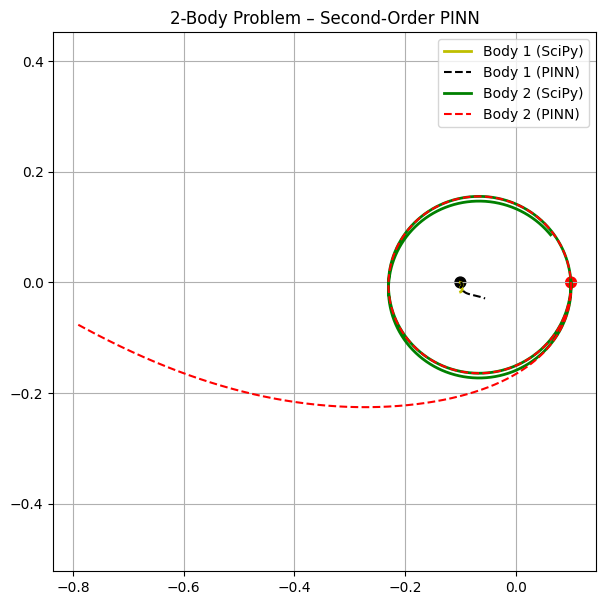

In [22]:
###############
############### ---  extrapolate  -----------
###############
xTime =2*endTime
# --------------------------------------------------
# Prediction
# --------------------------------------------------
t_test = np.linspace(0, xTime, 5000)[:, None]
y_pred = model.predict(t_test)

x1, y1 = y_pred[:, 0], y_pred[:, 1]
x2, y2 = y_pred[:, 2], y_pred[:, 3]

# --------------------------------------------------
# SciPy reference solution
# --------------------------------------------------
def two_body_rhs(t, y):
    x1, y1, vx1, vy1, x2, y2, vx2, vy2 = y
    r = ((x1-x2)**2 + (y1-y2)**2)**1.5

    ax1 = G*m2*(x2-x1)/r
    ay1 = G*m2*(y2-y1)/r
    ax2 = G*m1*(x1-x2)/r
    ay2 = G*m1*(y1-y2)/r

    return [vx1, vy1, ax1, ay1, vx2, vy2, ax2, ay2]

y0_full = np.array([
    x1_0, y1_0, vx1_0, vy1_0,
    x2_0, y2_0, vx2_0, vy2_0
])

sol = solve_ivp(
    two_body_rhs,
    (0,xTime),
    y0_full,
    t_eval=t_test.flatten(),
    rtol=1e-10,
    atol=1e-12,
)

# --------------------------------------------------
# Plot
# --------------------------------------------------
plt.figure(figsize=(7, 7))

plt.plot(sol.y[0], sol.y[1], "y-", lw=2, label="Body 1 (SciPy)")
plt.plot(x1, y1, "k--", lw=1.5, label="Body 1 (PINN)")

plt.plot(sol.y[4], sol.y[5], "g-", lw=2, label="Body 2 (SciPy)")
plt.plot(x2, y2, "r--", lw=1.5, label="Body 2 (PINN)")

plt.scatter([x1_0, x2_0], [y1_0, y2_0], c=["black", "red"], s=60)

plt.axis("equal")
plt.grid(True)
plt.legend()
plt.title("2-Body Problem – Second-Order PINN")
plt.show()